Neural Decoding with Temporal PCA (Derivative-based)
Total neurons: 1455
Total timepoints: 40000

Total stimulus presentations: 464
  Cinematic: 128 presentations
  Rendered: 128 presentations
  monet2: 40 presentations
  sports1m: 128 presentations
  trippy: 40 presentations

Extracting temporal PCA features with 100 components...
Stacked derivatives shape: (46400, 1455)
Total variance explained: 27.23%

Final feature shape: (464, 1500)
  (100 PCs × 15 features/PC = 1500 total features)

Class distribution: Counter({np.int64(2): 128, np.int64(0): 128, np.int64(1): 128, np.int64(3): 40, np.int64(4): 40})

Using saved parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2'}

Evaluating best model with 5-fold cross-validation
  Fold 1: Accuracy=66.67%, Balanced Acc=75.82%
  Fold 2: Accuracy=68.82%, Balanced Acc=77.29%
  Fold 3: Accuracy=66.67%, Balanced Acc=75.91%
  Fold 4: Accuracy=64.52%, Balanced Acc=74.28%
  Fold 5: Accuracy=57.61%, Balanced Acc=69.20%

Classification Report 

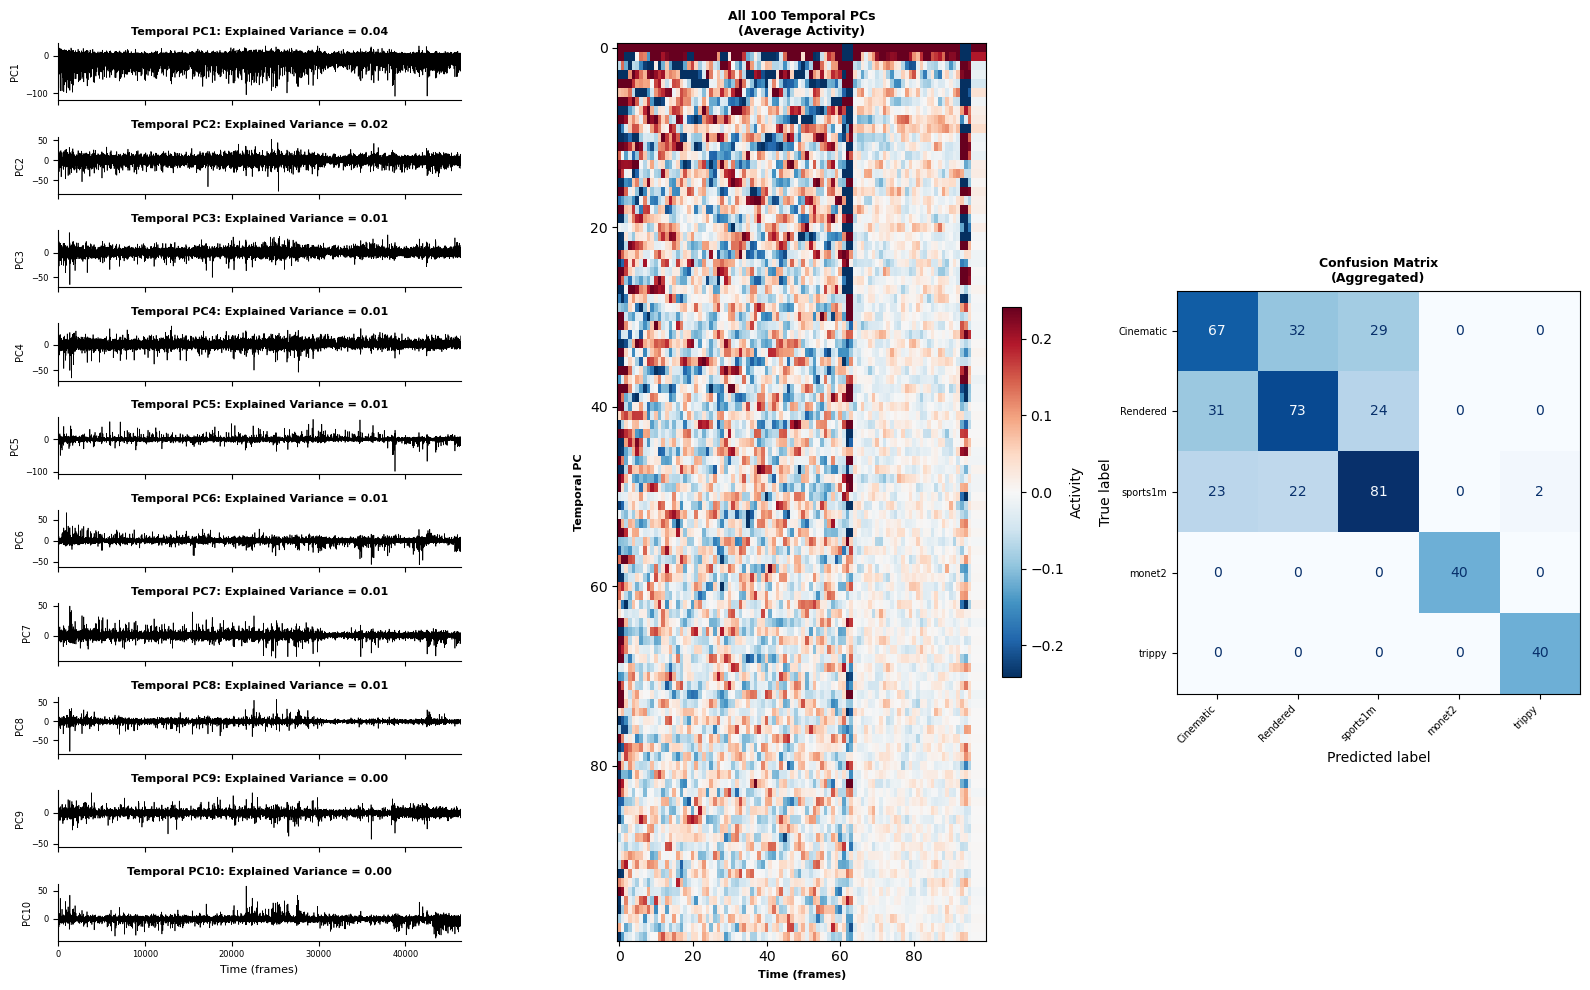

In [2]:
!pip install -q dandi remfile pynwb h5py scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import remfile
import h5py
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, balanced_accuracy_score
from collections import Counter

# ============================================================================
# Data Loading Functions
# ============================================================================

def connect_to_data():
    """Connect to the dataset and return the nwb file."""
    client = DandiAPIClient()
    dandiset = client.get_dandiset("000402", "draft")
    all_assets = dandiset.get_assets()

    asset = None
    for a in all_assets:
        if a.path.endswith(".nwb"):
            asset = a
            break

    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)
    rf = remfile.File(s3_url)
    h5 = h5py.File(rf, "r")
    io = NWBHDF5IO(file=h5, load_namespaces=True)
    nwb = io.read()

    return nwb


def get_neural_data(nwb):
    """Get the neural recording data."""
    ophys = nwb.processing["ophys"]
    fluorescence = ophys.data_interfaces["Fluorescence"]
    rs = fluorescence.roi_response_series["RoiResponseSeries3"]

    print("Total neurons:", rs.data.shape[1])
    print("Total timepoints:", rs.data.shape[0])

    return rs


def get_stimulus_info(nwb):
    """Get information about when stimuli were shown for ALL stimulus types."""
    
    all_starts = []
    all_stops = []
    all_types = []
    
    # Get Clip stimuli (Cinematic, Rendered, sports1m)
    clip_intervals = nwb.intervals['Clip']
    clip_starts = np.array(clip_intervals.start_time[:])
    clip_stops = np.array(clip_intervals.stop_time[:])
    clip_types = np.array(clip_intervals.short_movie_name[:])
    
    all_starts.extend(clip_starts)
    all_stops.extend(clip_stops)
    all_types.extend(clip_types)
    
    # Get Monet2 stimuli
    monet_intervals = nwb.intervals['Monet2']
    monet_starts = np.array(monet_intervals.start_time[:])
    monet_stops = np.array(monet_intervals.stop_time[:])
    monet_types = np.array(['monet2'] * len(monet_starts))
    
    all_starts.extend(monet_starts)
    all_stops.extend(monet_stops)
    all_types.extend(monet_types)
    
    # Get Trippy stimuli
    trippy_intervals = nwb.intervals['Trippy']
    trippy_starts = np.array(trippy_intervals.start_time[:])
    trippy_stops = np.array(trippy_intervals.stop_time[:])
    trippy_types = np.array(['trippy'] * len(trippy_starts))
    
    all_starts.extend(trippy_starts)
    all_stops.extend(trippy_stops)
    all_types.extend(trippy_types)
    
    # Convert to arrays
    all_starts = np.array(all_starts)
    all_stops = np.array(all_stops)
    all_types = np.array(all_types)
    
    print("\nTotal stimulus presentations:", len(all_starts))
    unique_types = np.unique(all_types)
    for stim_type in unique_types:
        count = np.sum(all_types == stim_type)
        print(f"  {stim_type}: {count} presentations")

    return all_starts, all_stops, all_types


# ============================================================================
# Temporal PCA Feature Extraction
# ============================================================================

def extract_tpca_features(rs, timestamps, clip_starts, clip_stops, clip_types,
                         target_conditions, n_components=5, max_timepoints=100, 
                         include_frequency_features=True):
    """
    Extract temporal PCA features by:
    1. Computing temporal derivative (gradient) for each trial
    2. Fitting PCA on derivatives across neurons
    3. Using PC loadings as features for classification
    
    Enhanced version with frequency domain features and richer temporal statistics.
    """
    
    condition_names = {cond: i for i, cond in enumerate(target_conditions)}
    
    # Step 1: Collect all trial data and compute derivatives
    all_derivatives = []
    all_raw_data = []
    all_labels = []
    
    print(f"\nExtracting temporal PCA features with {n_components} components...")
    
    for i in range(len(clip_starts)):
        stim_type = clip_types[i]
        if stim_type not in target_conditions:
            continue

        start_time = clip_starts[i]
        stop_time = clip_stops[i]
        start_idx = np.searchsorted(timestamps, start_time)
        stop_idx = np.searchsorted(timestamps, stop_time)

        # Get neural data for this trial: [time x neurons]
        neural_chunk = np.array(rs.data[start_idx:stop_idx, :])
        
        # Truncate or pad to fixed length
        if neural_chunk.shape[0] > max_timepoints:
            neural_chunk = neural_chunk[:max_timepoints, :]
        elif neural_chunk.shape[0] < max_timepoints:
            padding = np.zeros((max_timepoints - neural_chunk.shape[0], neural_chunk.shape[1]))
            neural_chunk = np.vstack([neural_chunk, padding])
        
        # Compute temporal derivative (gradient along time axis)
        derivative = np.gradient(neural_chunk, axis=0)
        
        all_derivatives.append(derivative)
        all_raw_data.append(neural_chunk)
        all_labels.append(condition_names[stim_type])
    
    # Step 2: Fit PCA on derivatives
    stacked_derivatives = np.vstack(all_derivatives)
    
    print(f"Stacked derivatives shape: {stacked_derivatives.shape}")
    
    scaler = StandardScaler()
    stacked_derivatives_scaled = scaler.fit_transform(stacked_derivatives)
    
    tpca = PCA(n_components=n_components, random_state=42)
    tpca.fit(stacked_derivatives_scaled)
    
    print(f"Total variance explained: {np.sum(tpca.explained_variance_ratio_)*100:.2f}%")
    
    # Step 3: Extract richer features from temporal PCs
    all_features = []
    
    for derivative, raw_data in zip(all_derivatives, all_raw_data):
        derivative_scaled = scaler.transform(derivative)
        pc_timecourse = tpca.transform(derivative_scaled)
        
        features = []
        for pc_idx in range(n_components):
            tc = pc_timecourse[:, pc_idx]
            
            # Time domain statistics
            features.append(np.mean(tc))
            features.append(np.std(tc))
            features.append(np.max(tc))
            features.append(np.min(tc))
            features.append(np.median(tc))
            features.append(np.percentile(tc, 25))  # Q1
            features.append(np.percentile(tc, 75))  # Q3
            features.append(np.ptp(tc))  # Peak-to-peak
            
            # Temporal dynamics
            if len(tc) > 1:
                features.append(np.mean(np.abs(np.diff(tc))))  # Mean change rate
                features.append(np.argmax(np.abs(tc)))  # Time of peak activity
            
            # Frequency domain features
            if include_frequency_features and len(tc) > 4:
                # Compute FFT
                fft_vals = np.fft.rfft(tc)
                fft_freqs = np.fft.rfftfreq(len(tc))
                
                # Power spectrum
                power = np.abs(fft_vals) ** 2
                
                # Frequency features
                features.append(np.mean(power))  # Average power
                features.append(np.max(power))   # Peak power
                
                # Dominant frequency (frequency with max power, excluding DC)
                if len(power) > 1:
                    features.append(fft_freqs[np.argmax(power[1:]) + 1])
                else:
                    features.append(0)
                
                # Spectral centroid (weighted mean frequency)
                if np.sum(power) > 0:
                    features.append(np.sum(fft_freqs * power) / np.sum(power))
                else:
                    features.append(0)
                
                # Low/high frequency power ratio
                mid_idx = len(power) // 2
                low_power = np.sum(power[:mid_idx])
                high_power = np.sum(power[mid_idx:])
                if high_power > 0:
                    features.append(low_power / high_power)
                else:
                    features.append(low_power)
        
        all_features.append(features)
    
    X = np.array(all_features)
    y = np.array(all_labels)
    
    features_per_pc = len(features) // n_components
    print(f"\nFinal feature shape: {X.shape}")
    print(f"  ({n_components} PCs × {features_per_pc} features/PC = {X.shape[1]} total features)")
    
    return X, y, condition_names, tpca, all_derivatives, scaler


# ============================================================================
# Model Training and Evaluation
# ============================================================================

def train_and_evaluate(X, y, condition_names, n_folds=5, retune=True, saved_params=None):
    """
    Train logistic regression with grid search and evaluate with confusion matrix.
    
    Args:
        retune: If True, perform grid search. If False, use saved_params.
        saved_params: Previously found best parameters (optional).
    
    Returns:
        cm: Confusion matrix
        class_names: List of class names
        fold_accuracies: List of fold accuracies
        fold_balanced_accuracies: List of fold balanced accuracies
    """
    
    print(f"\nClass distribution: {Counter(y)}")
    
    # Pipeline: scaling + logistic regression with balanced class weights
    from sklearn.model_selection import GridSearchCV
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            random_state=42, 
            class_weight='balanced',
            max_iter=10000,
            solver='saga'
        ))
    ])
    
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    if retune:
        # Grid search for best hyperparameters
        param_grid = [
            {
                'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
                'classifier__penalty': ['l1', 'l2'],
            },
            {
                'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
                'classifier__penalty': ['elasticnet'],
                'classifier__l1_ratio': [0.3, 0.5, 0.7]
            }
        ]
        
        print(f"\nPerforming hyperparameter tuning with {n_folds}-fold CV")
        
        # Grid search
        grid_search = GridSearchCV(
            pipeline, 
            param_grid, 
            cv=cv, 
            scoring='balanced_accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X, y)
        
        best_params = grid_search.best_params_
        print(f"\nBest parameters: {best_params}")
        print(f"Best CV balanced accuracy: {grid_search.best_score_*100:.2f}%")
        
        best_pipeline = grid_search.best_estimator_
    else:
        # Use saved parameters
        if saved_params is None:
            raise ValueError("Must provide saved_params when retune=False")
        
        print(f"\nUsing saved parameters: {saved_params}")
        
        # Set the parameters
        for param, value in saved_params.items():
            param_name = param.replace('classifier__', '')
            setattr(pipeline.named_steps['classifier'], param_name, value)
        
        best_pipeline = pipeline
        best_params = saved_params
    
    fold_accuracies = []
    fold_balanced_accuracies = []
    all_y_true = []
    all_y_pred = []
    
    print(f"\nEvaluating best model with {n_folds}-fold cross-validation")
    
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Clone the best pipeline for this fold
        from sklearn.base import clone
        fold_pipeline = clone(best_pipeline)
        fold_pipeline.fit(X_train, y_train)
        y_pred = fold_pipeline.predict(X_test)
        
        accuracy = np.mean(y_test == y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        
        fold_accuracies.append(accuracy)
        fold_balanced_accuracies.append(balanced_acc)
        
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        
        print(f"  Fold {fold_idx+1}: Accuracy={accuracy*100:.2f}%, Balanced Acc={balanced_acc*100:.2f}%")
    
    # Classification report
    class_names = [k for k, v in sorted(condition_names.items(), key=lambda x: x[1])]
    
    print("\n" + "="*70)
    print("Classification Report (aggregated across folds):")
    print("="*70)
    print(classification_report(all_y_true, all_y_pred, target_names=class_names, digits=3))
    
    print(f"\nOverall Accuracy: {np.mean(fold_accuracies)*100:.2f}% ± {np.std(fold_accuracies)*100:.2f}%")
    print(f"Overall Balanced Accuracy: {np.mean(fold_balanced_accuracies)*100:.2f}% ± {np.std(fold_balanced_accuracies)*100:.2f}%")
    
    # Confusion matrix
    cm = confusion_matrix(all_y_true, all_y_pred)
    
    return cm, class_names, fold_accuracies, fold_balanced_accuracies


# ============================================================================
# Visualization
# ============================================================================

def plot_results(cm, class_names, tpca, fold_balanced_accuracies, all_derivatives, scaler):
    """Create visualization plots with individual trial traces."""
    
    fontsize = 8
    n_pcs_to_plot = min(10, len(tpca.components_))  # Show up to 10 PCs
    
    # Create a comprehensive figure
    fig = plt.figure(figsize=(16, 10))
    
    # Left side: Temporal PC time series - CONCATENATED ACROSS ALL TRIALS
    for i in range(n_pcs_to_plot):
        ax = plt.subplot(n_pcs_to_plot, 3, i*3 + 1)
        
        # Concatenate ALL trial timecourses into one long continuous signal
        continuous_pc = []
        for derivative in all_derivatives:
            derivative_scaled = scaler.transform(derivative)
            pc_timecourse = tpca.transform(derivative_scaled)
            continuous_pc.extend(pc_timecourse[:, i])
        
        continuous_pc = np.array(continuous_pc)
        time = np.arange(len(continuous_pc))
        
        # Plot as single continuous trace
        ax.plot(time, continuous_pc, color='black', linewidth=0.5)
        
        ax.set_title(f'Temporal PC{i+1}: Explained Variance = {tpca.explained_variance_ratio_[i]:.2f}', 
                    fontsize=fontsize, fontweight='bold')
        ax.set_ylabel(f'PC{i+1}', fontsize=fontsize-1)
        ax.tick_params(axis='both', labelsize=fontsize-2)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_xlim([0, len(time)])
        
        if i == n_pcs_to_plot - 1:
            ax.set_xlabel('Time (frames)', fontsize=fontsize)
        else:
            ax.set_xticklabels([])
    
    # Middle: All PCs heatmap
    ax_heatmap = plt.subplot(1, 3, 2)
    
    # Create heatmap of all PC timecourses
    all_pcs_avg = []
    for i in range(len(tpca.components_)):
        all_pc_timecourses = []
        for derivative in all_derivatives:
            derivative_scaled = scaler.transform(derivative)
            pc_timecourse = tpca.transform(derivative_scaled)
            all_pc_timecourses.append(pc_timecourse[:, i])
        avg_pc_timecourse = np.mean(all_pc_timecourses, axis=0)
        all_pcs_avg.append(avg_pc_timecourse)
    
    pc_matrix = np.array(all_pcs_avg)
    im = ax_heatmap.imshow(pc_matrix, aspect='auto', cmap='RdBu_r', 
                           vmin=-np.percentile(np.abs(pc_matrix), 95),
                           vmax=np.percentile(np.abs(pc_matrix), 95))
    ax_heatmap.set_xlabel('Time (frames)', fontsize=fontsize, fontweight='bold')
    ax_heatmap.set_ylabel('Temporal PC', fontsize=fontsize, fontweight='bold')
    ax_heatmap.set_title(f'All {len(tpca.components_)} Temporal PCs\n(Average Activity)', 
                        fontsize=fontsize+1, fontweight='bold')
    plt.colorbar(im, ax=ax_heatmap, label='Activity', fraction=0.046, pad=0.04)
    
    # Right: Confusion Matrix
    ax_cm = plt.subplot(1, 3, 3)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax_cm, cmap='Blues', values_format='d', colorbar=False)
    ax_cm.set_title('Confusion Matrix\n(Aggregated)', fontsize=fontsize+1, fontweight='bold')
    plt.setp(ax_cm.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize-1)
    plt.setp(ax_cm.get_yticklabels(), fontsize=fontsize-1)
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# Main Analysis
# ============================================================================

print("="*70)
print("Neural Decoding with Temporal PCA (Derivative-based)")
print("="*70)

# Load data
nwb = connect_to_data()
rs = get_neural_data(nwb)
clip_starts, clip_stops, clip_types = get_stimulus_info(nwb)

timestamps = np.array(rs.timestamps[:100000])

# All 5 stimulus types
target_conditions = ['Cinematic', 'Rendered', 'sports1m', 'monet2', 'trippy']

# Extract temporal PCA features
n_components = 100  # Increased to capture more variance
X, y, condition_names, tpca, all_derivatives, scaler = extract_tpca_features(
    rs, timestamps, clip_starts, clip_stops, clip_types,
    target_conditions, n_components=n_components, max_timepoints=100,
    include_frequency_features=True  # Enable frequency features
)

# Train and evaluate
# FIRST RUN: Set retune=True to find best parameters
# LATER RUNS: Set retune=False and paste the saved_params here

RETUNE = False
SAVED_PARAMS = {'classifier__C': 0.01, 'classifier__penalty': 'l2'} # After first run, paste the best parameters here

cm, class_names, fold_accs, fold_bal_accs = train_and_evaluate(
    X, y, condition_names, n_folds=5, 
    retune=RETUNE, 
    saved_params=SAVED_PARAMS
)

# Visualize results
plot_results(cm, class_names, tpca, fold_bal_accs, all_derivatives, scaler)
